# Prepare Clinical data

In [1]:
BINARY_PFS = True
RNA_SEQ_ONLY = False

LONG_RESP_THRESHOLD = 12
SHORT_RESP_THRESHOLD = 6
DROP_BOR = True

import os
pfs_dir = "binary" if BINARY_PFS else "three-classes"
rna_suffix = "_rna" if RNA_SEQ_ONLY else ""

In [2]:
import pandas as pd
import numpy as np

source_map = {
    'doi:10.1016/j.cell.2015.07.061': 'Hugo et al.',
    'doi:10.1172/JCI78954DS1': 'Kwong et al.',
    'doi:10.1158/1078-0432.CCR-18-0720': 'Yan et al.',
    'doi:10.3390/cancers11081203': 'Louveau et al.',
    'doi:10.1038/ncomms6694': 'Long et al.',
    'doi:10.1158/1078-0432.CCR-13-3122': 'Rizos et al.',
    "doi:10.3390/cancers12082224": 'Blateau et al.',
    "doi:10.1200/PO.16.00054": 'Catalanotti et al.',
    'doi:10.1158/2159-8290.CD-13-0617': 'Van Allen at al.'
}

clinical = pd.read_csv("../dataset/original/clinical.csv")
clinical['patientID'] = clinical['patientID'].str.replace(r'^HL_', 'HL_Shi-', regex=True)
clinical['source'] = clinical['source'].replace(source_map)
if RNA_SEQ_ONLY == True:
    clinical = clinical[clinical['source'].isin(['Hugo et al.', 'Kwong et al.', 'Yan et al.'])]
clinical = clinical.drop(columns=['id', 'creation_datetime', 'original_patientID', 'OS_status', 'OS_month', 'CNA_data', 'SNV_data', 'GEX_data'])

if DROP_BOR == True:
    clinical = clinical.drop(columns=['BOR'])

print(clinical.shape)
clinical.head()

(417, 14)


,patientID,sex,age,AJCC_stage,M_stage,LDH,PFS_status,PFS_month,drug,BRAF_mut,brain_metastasis,immunotherapy_treatment,pre_MAPKi_treatment,source
0,BS_000,male,56,IV,NaN,normal,1.0,30.5,dabrafenib + trametinib,V600E,no,no,no,Blateau et al.
1,BS_001,male,86,IV,NaN,normal,0.0,24.1,dabrafenib,V600E,no,no,no,Blateau et al.
2,BS_002,female,47,IV,NaN,normal,0.0,14.1,dabrafenib + trametinib,V600E,no,no,no,Blateau et al.
3,BS_003,female,50,IV,NaN,NaN,1.0,1.6,vemurafenib,V600E,no,no,no,Blateau et al.
4,BS_004,female,47,IV,NaN,elevated,1.0,11.9,dabrafenib + trametinib,V600K,no,no,no,Blateau et al.


In [3]:
clinical['source'].unique()

array(['Blateau et al.', 'Catalanotti et al.', 'Van Allen at al.',
       'Yan et al.', 'Louveau et al.', 'Rizos et al.', 'Long et al.',
       'Kwong et al.', 'Hugo et al.'], dtype=object)

## Check KM Curve

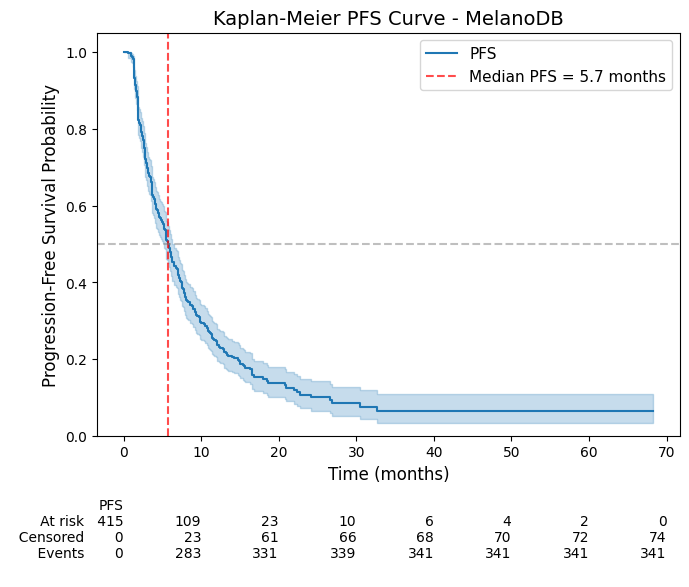

Median PFS: 5.7 months
Total patients: 415
Events (progressions): 341
Censored: 74


In [4]:
from lifelines import KaplanMeierFitter
import matplotlib.pyplot as plt

df = clinical.dropna(subset=['PFS_month', 'PFS_status']).copy()

kmf = KaplanMeierFitter()

kmf.fit(
    durations=df['PFS_month'],
    event_observed=df['PFS_status'],  # 1 = progression, 0 = censored
    label='PFS'
)

# Plot
fig, ax = plt.subplots(figsize=(7, 6))

kmf.plot_survival_function(
    ax=ax,
    ci_show=True,          # show 95% confidence interval
    at_risk_counts=True,   # show number at risk below plot
)

# Add median line
median_pfs = kmf.median_survival_time_
ax.axvline(x=median_pfs, color='red', linestyle='--', alpha=0.7, label=f'Median PFS = {median_pfs:.1f} months')
ax.axhline(y=0.5, color='gray', linestyle='--', alpha=0.5)

ax.set_xlabel('Time (months)', fontsize=12)
ax.set_ylabel('Progression-Free Survival Probability', fontsize=12)
ax.set_title('Kaplan-Meier PFS Curve - MelanoDB', fontsize=14)
ax.legend(fontsize=11)
ax.set_ylim(0, 1.05)

plt.tight_layout()
plt.savefig('km_curve.png', dpi=150)
plt.show()

print(f'Median PFS: {median_pfs:.1f} months')
print(f'Total patients: {len(df)}')
print(f'Events (progressions): {int(df["PFS_status"].sum())}')
print(f'Censored: {int((df["PFS_status"] == 0).sum())}')

## Add Target label

In [5]:
# Check unexpected PFS_status values
print(clinical['PFS_status'].value_counts(dropna=False))

PFS_status
1.0    341
0.0     74
NaN      2
Name: count, dtype: int64


In [6]:
clinical['PFS_status'] = pd.to_numeric(clinical['PFS_status'], errors='coerce')

def label_pfs(row):
    if BINARY_PFS == False:
        if row['PFS_month'] >= LONG_RESP_THRESHOLD:
            return 2
        elif row['PFS_month'] < SHORT_RESP_THRESHOLD and row['PFS_status'] == 1:
            return 0
        elif row['PFS_month'] >= SHORT_RESP_THRESHOLD and row['PFS_month'] < LONG_RESP_THRESHOLD and row['PFS_status'] == 1:
            return 1
        return np.nan
    
    else:
        if row['PFS_month'] >= LONG_RESP_THRESHOLD:
            return 1
        elif row['PFS_month'] < SHORT_RESP_THRESHOLD and row['PFS_status'] == 1:
            return 0
        return np.nan

clinical['pfs_label'] = clinical.apply(label_pfs, axis=1)
clinical = clinical.drop(columns=['PFS_status']).dropna(subset=['pfs_label'])
clinical['pfs_label'] = clinical['pfs_label'].astype(int)

print(clinical.shape)
clinical.head()


(295, 14)


,patientID,sex,age,AJCC_stage,M_stage,LDH,PFS_month,drug,BRAF_mut,brain_metastasis,immunotherapy_treatment,pre_MAPKi_treatment,source,pfs_label
0,BS_000,male,56,IV,NaN,normal,30.5,dabrafenib + trametinib,V600E,no,no,no,Blateau et al.,1
1,BS_001,male,86,IV,NaN,normal,24.1,dabrafenib,V600E,no,no,no,Blateau et al.,1
2,BS_002,female,47,IV,NaN,normal,14.1,dabrafenib + trametinib,V600E,no,no,no,Blateau et al.,1
3,BS_003,female,50,IV,NaN,NaN,1.6,vemurafenib,V600E,no,no,no,Blateau et al.,0
11,BS_011,female,63,IV,NaN,elevated,3.0,dabrafenib + trametinib,V600E,yes,no,no,Blateau et al.,0


In [7]:
clinical['pfs_label'].value_counts().sort_index()

pfs_label
0    209
1     86
Name: count, dtype: int64

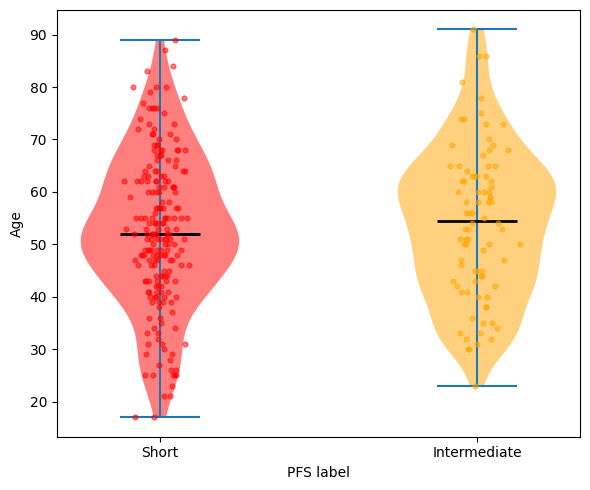

In [8]:
import matplotlib.pyplot as plt

label_names = {0: 'Short', 1: 'Intermediate', 2: 'Long'}
colors = ['red', 'orange', 'green']
labels = sorted(clinical['pfs_label'].unique())

data = [clinical[clinical['pfs_label'] == l]['age'].dropna().values for l in labels]

fig, ax = plt.subplots(figsize=(6, 5))

vp = ax.violinplot(data, positions=range(len(labels)), showmedians=True, bw_method=0.3)
for pc, color in zip(vp['bodies'], colors):
    pc.set_facecolor(color)
    pc.set_alpha(0.5)
vp['cmedians'].set_color('black')
vp['cmedians'].set_linewidth(2)

for i, (d, color) in enumerate(zip(data, colors)):
    ax.scatter(np.random.normal(i, 0.04, size=len(d)), d, alpha=0.5, s=12, color=color, zorder=3)

ax.set_xticks(range(len(labels)))
ax.set_xticklabels([label_names[l] for l in labels])
ax.set_ylabel('Age')
ax.set_xlabel('PFS label')
plt.tight_layout()
plt.show()

## OHE 'drug' and 'BRAF_mut'

In [9]:
drug_series = clinical['drug'].fillna('').str.replace(r'\s*\+\s*', '+', regex=True).str.strip()
drug_dummies = drug_series.str.get_dummies(sep='+').drop(columns=[''], errors='ignore')
clinical = pd.concat([clinical.drop('drug', axis=1), drug_dummies], axis=1)

braf_series = clinical['BRAF_mut'].fillna('').str.replace(r'\s*;\s*', ';', regex=True).str.strip()
braf_mut_dummies = braf_series.str.get_dummies(sep=';').drop(columns=[''], errors='ignore')
clinical = pd.concat([clinical.drop('BRAF_mut', axis=1), braf_mut_dummies], axis=1)
clinical = clinical.drop(columns=['nan'], errors='ignore')

print(clinical.shape)
clinical.head()

(295, 20)


,patientID,sex,age,AJCC_stage,M_stage,LDH,PFS_month,brain_metastasis,immunotherapy_treatment,pre_MAPKi_treatment,source,pfs_label,cobimetinib,dabrafenib,trametinib,vemurafenib,MND,V600E,V600K,V600R
0,BS_000,male,56,IV,NaN,normal,30.5,no,no,no,Blateau et al.,1,0,1,1,0,0,1,0,0
1,BS_001,male,86,IV,NaN,normal,24.1,no,no,no,Blateau et al.,1,0,1,0,0,0,1,0,0
2,BS_002,female,47,IV,NaN,normal,14.1,no,no,no,Blateau et al.,1,0,1,1,0,0,1,0,0
3,BS_003,female,50,IV,NaN,NaN,1.6,no,no,no,Blateau et al.,0,0,0,0,1,0,1,0,0
11,BS_011,female,63,IV,NaN,elevated,3.0,yes,no,no,Blateau et al.,0,0,1,1,0,0,1,0,0


In [10]:
os.makedirs(f"../dataset/created/{pfs_dir}", exist_ok=True)
clinical.to_csv(f"../dataset/created/{pfs_dir}/clinical{rna_suffix}.csv", index=False)